In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the exchange rate dataset
df = pd.read_csv("data/exchange_rate.csv")

# Display the column names
print("Column Names:")
print(df.columns.tolist())

# Display the first 10 rows
print("\nFirst 10 rows:")
display(df.head(10))

# Check the data types
print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Column Names:
['date', 'Ex_rate']

First 10 rows:


,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849
5,06-01-1990 00:00,0.7866
6,07-01-1990 00:00,0.7886
7,08-01-1990 00:00,0.7910
8,09-01-1990 00:00,0.7939
9,10-01-1990 00:00,0.7894



Data Types:
date           str
Ex_rate    float64
dtype: object

Missing Values:
date       0
Ex_rate    0
dtype: int64


In [5]:
# Load the dataset
df = pd.read_csv("data/exchange_rate.csv")

# Inspect the actual date values
print("Column names:")
print(df.columns.tolist())

print("\nFirst 10 rows:")
display(df.head(10))

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Column names:
['date', 'Ex_rate']

First 10 rows:


,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849
5,06-01-1990 00:00,0.7866
6,07-01-1990 00:00,0.7886
7,08-01-1990 00:00,0.7910
8,09-01-1990 00:00,0.7939
9,10-01-1990 00:00,0.7894



Data types:
date           str
Ex_rate    float64
dtype: object

Missing values:
date       0
Ex_rate    0
dtype: int64


In [6]:
# Convert the date column to datetime
df['date'] = pd.to_datetime(
    df['date'],
    format='%d-%m-%Y %H:%M'
)

# Sort data by date
df = df.sort_values('date').reset_index(drop=True)

# Display the result
print("Date conversion successful!")

print("\nData types:")
print(df.dtypes)

print("\nDate range:")
print("Start date:", df['date'].min())
print("End date:", df['date'].max())

print("\nFirst 5 rows:")
display(df.head())

Date conversion successful!

Data types:
date       datetime64[us]
Ex_rate           float64
dtype: object

Date range:
Start date: 1990-01-01 00:00:00
End date: 2010-10-10 00:00:00

First 5 rows:


,date,Ex_rate
0,1990-01-01,0.7855
1,1990-01-02,0.7818
2,1990-01-03,0.7867
3,1990-01-04,0.7860
4,1990-01-05,0.7849


In [7]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Check duplicate dates
print("\nDuplicate dates:", df['date'].duplicated().sum())

# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Missing values:
date       0
Ex_rate    0
dtype: int64

Duplicate dates: 0
Duplicate rows: 0


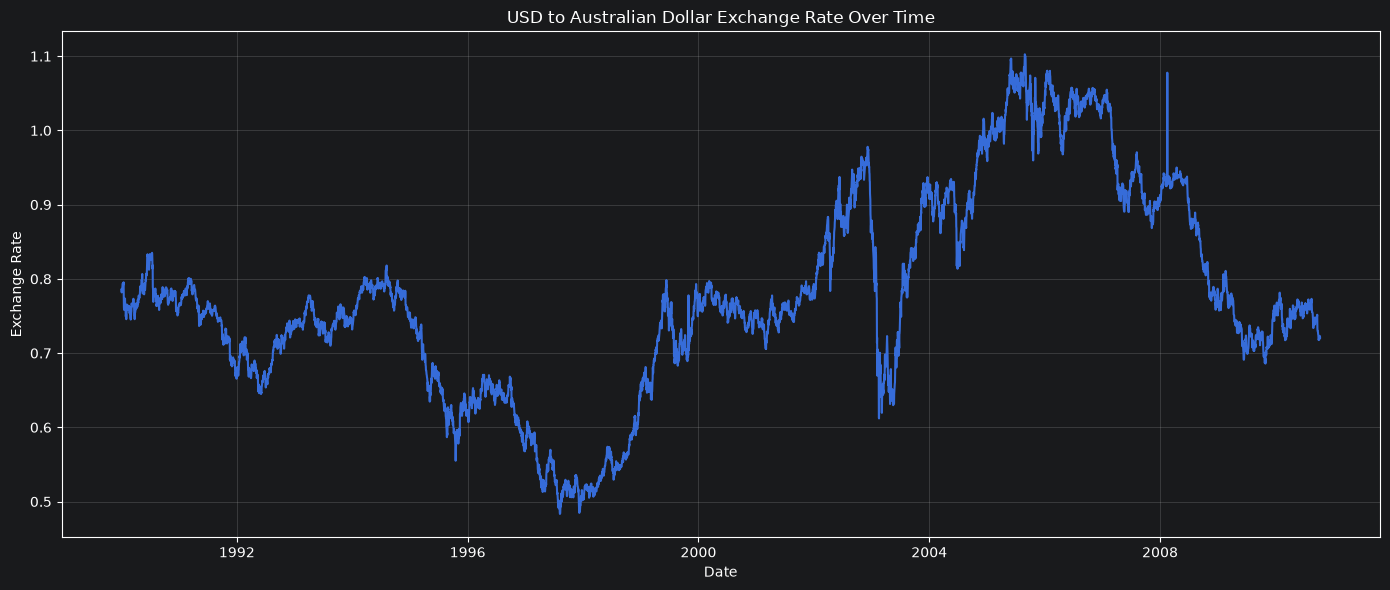

In [8]:
# Plot the exchange rate over time

plt.figure(figsize=(14, 6))

plt.plot(df['date'], df['Ex_rate'])

plt.title('USD to Australian Dollar Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

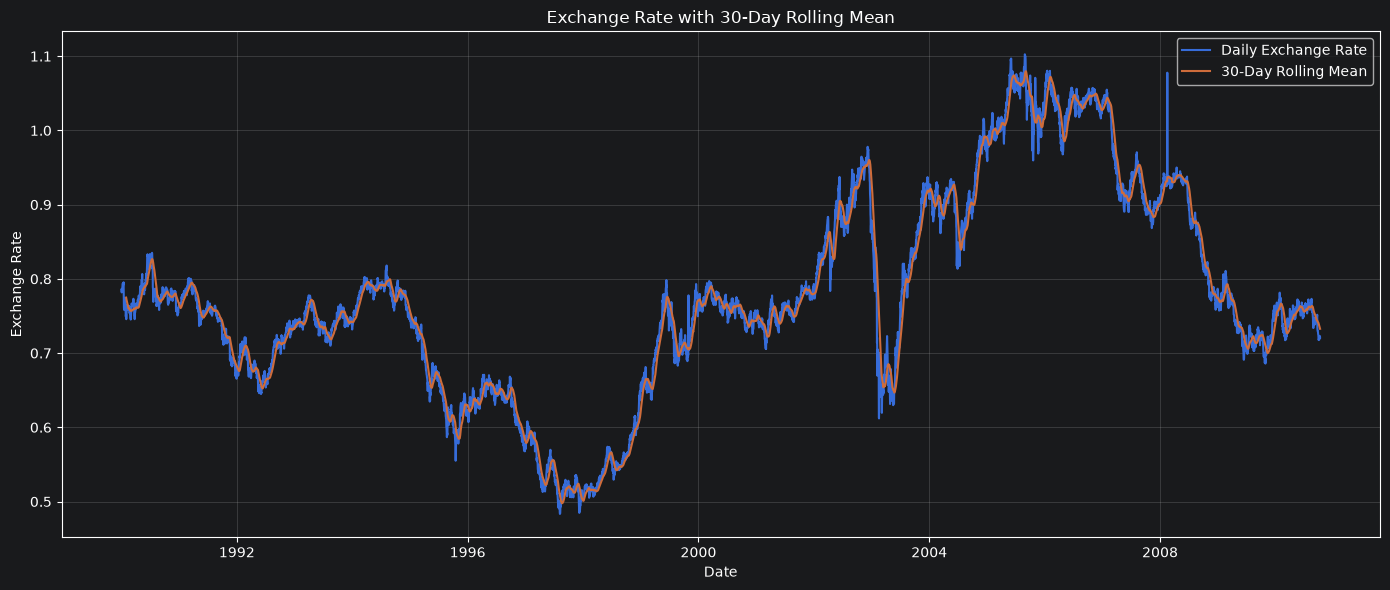

In [9]:
# Plot exchange rate with a rolling mean

df['Rolling_Mean_30'] = df['Ex_rate'].rolling(window=30).mean()

plt.figure(figsize=(14, 6))

plt.plot(df['date'], df['Ex_rate'], label='Daily Exchange Rate')
plt.plot(df['date'], df['Rolling_Mean_30'], label='30-Day Rolling Mean')

plt.title('Exchange Rate with 30-Day Rolling Mean')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
from statsmodels.tsa.stattools import adfuller

# Perform Augmented Dickey-Fuller test
adf_result = adfuller(df['Ex_rate'])

print("ADF Test Results")
print("----------------")
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Number of Lags Used:", adf_result[2])
print("Number of Observations:", adf_result[3])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

# Interpret the result
if adf_result[1] < 0.05:
    print("\nConclusion: The series is stationary.")
else:
    print("\nConclusion: The series is non-stationary.")

ADF Test Results
----------------
ADF Statistic: -1.6649941807381368
p-value: 0.4492327353597985
Number of Lags Used: 1
Number of Observations: 7586

Critical Values:
1%: -3.4312123140180137
5%: -2.861921078147796
10%: -2.5669728434336108

Conclusion: The series is non-stationary.


In [12]:
# First-order differencing
df['Ex_rate_diff'] = df['Ex_rate'].diff()

# Remove the first NaN created by differencing
diff_series = df['Ex_rate_diff'].dropna()

# Display first few differenced values
print("First 10 differenced values:")
display(diff_series.head(10))

# Perform ADF test again
adf_diff = adfuller(diff_series)

print("\nADF Test After First Differencing")
print("----------------------------------")
print("ADF Statistic:", adf_diff[0])
print("p-value:", adf_diff[1])

print("\nCritical Values:")
for key, value in adf_diff[4].items():
    print(f"{key}: {value}")

if adf_diff[1] < 0.05:
    print("\nConclusion: The differenced series is stationary.")
else:
    print("\nConclusion: The differenced series is still non-stationary.")

First 10 differenced values:


1    -0.0037
2     0.0049
3    -0.0007
4    -0.0011
5     0.0017
6     0.0020
7     0.0024
8     0.0029
9    -0.0045
10    0.0023
Name: Ex_rate_diff, dtype: float64


ADF Test After First Differencing
----------------------------------
ADF Statistic: -99.39343120118629
p-value: 0.0

Critical Values:
1%: -3.4312123140180137
5%: -2.861921078147796
10%: -2.5669728434336108

Conclusion: The differenced series is stationary.


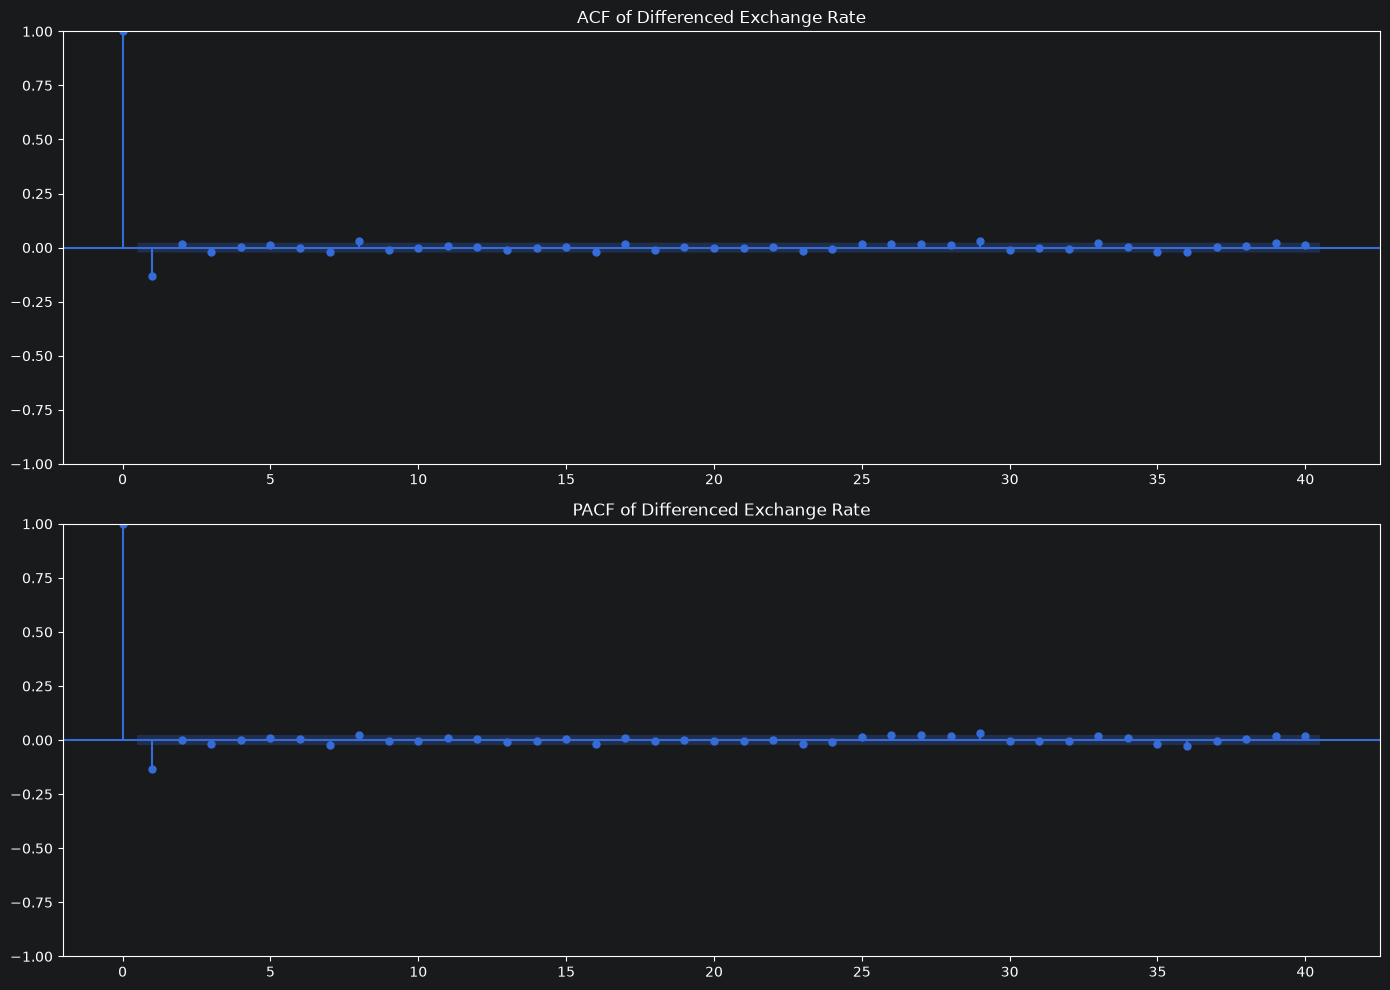

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Create ACF and PACF plots for the stationary differenced series
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ACF plot
plot_acf(diff_series, ax=axes[0], lags=40)
axes[0].set_title('ACF of Differenced Exchange Rate')

# PACF plot
plot_pacf(diff_series, ax=axes[1], lags=40, method='ywm')
axes[1].set_title('PACF of Differenced Exchange Rate')

plt.tight_layout()
plt.show()

In [14]:
from statsmodels.tsa.arima.model import ARIMA

# Define candidate ARIMA models
models = {
    'ARIMA(0,1,1)': (0, 1, 1),
    'ARIMA(1,1,0)': (1, 1, 0),
    'ARIMA(1,1,1)': (1, 1, 1)
}

# Store model results
results = []

for name, order in models.items():
    model = ARIMA(df['Ex_rate'], order=order)
    fitted_model = model.fit()

    results.append({
        'Model': name,
        'AIC': fitted_model.aic,
        'BIC': fitted_model.bic
    })

# Create comparison table
arima_comparison = pd.DataFrame(results)

print("ARIMA Model Comparison")
print("----------------------")
display(arima_comparison.sort_values('AIC'))

ARIMA Model Comparison
----------------------


,Model,AIC,BIC
1,"ARIMA(1,1,0)",-56104.318870,-56090.450487
0,"ARIMA(0,1,1)",-56102.753412,-56088.885029
2,"ARIMA(1,1,1)",-56102.321674,-56081.519099


In [15]:
# Fit the selected ARIMA(1,1,0) model

arima_model = ARIMA(df['Ex_rate'], order=(1, 1, 0))
arima_fitted = arima_model.fit()

# Display model summary
print(arima_fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 0)   Log Likelihood               28054.159
Date:                Sun, 23 Aug 2026   AIC                         -56104.319
Time:                        18:04:07   BIC                         -56090.450
Sample:                             0   HQIC                        -56099.559
                               - 7588                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1314      0.002    -64.439      0.000      -0.135      -0.127
sigma2      3.595e-05   9.94e-08    361.720      0.000    3.58e-05    3.61e-05
Ljung-Box (L1) (Q):                   0.00   Jarque-

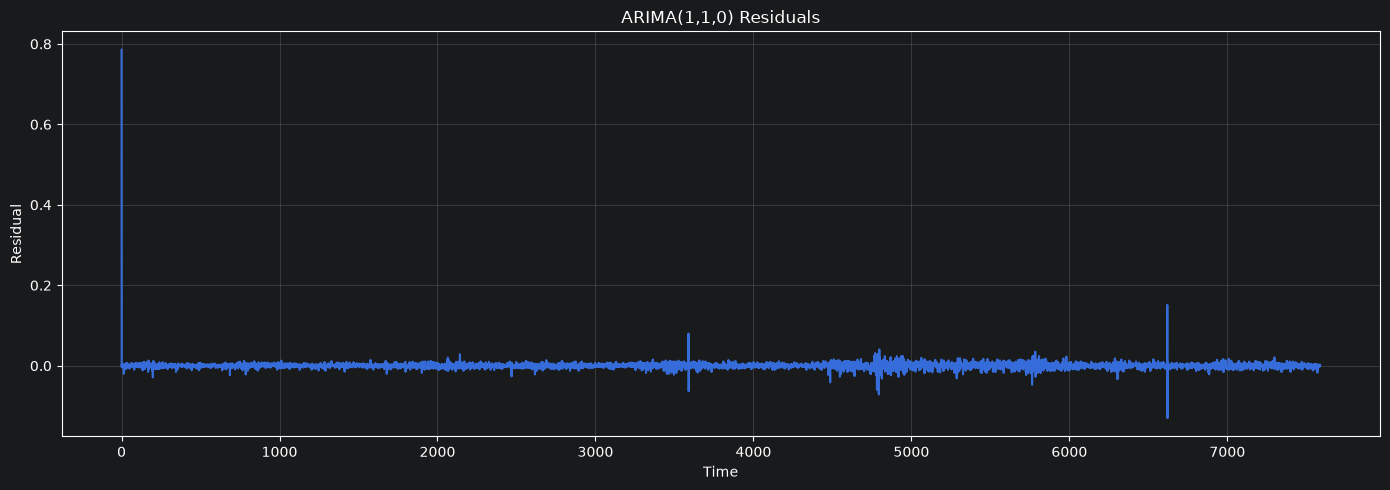

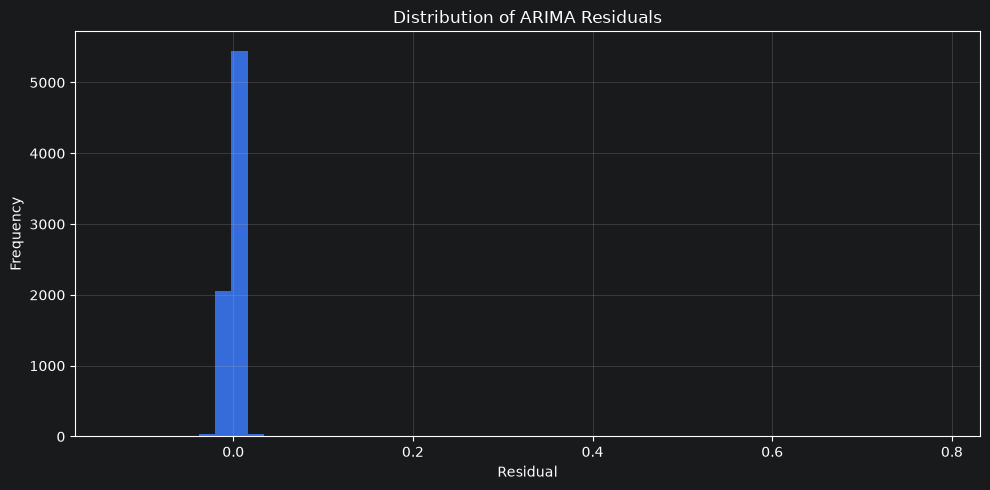

<Figure size 1200x500 with 0 Axes>

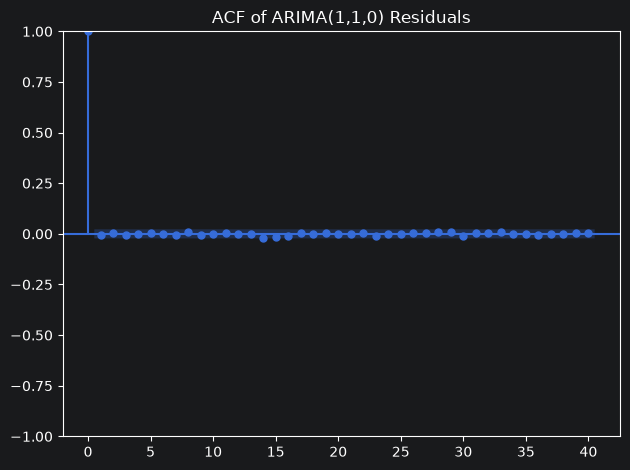

Ljung-Box Test Results
----------------------


,lb_stat,lb_pvalue
10,1.806741,0.997618
20,7.114287,0.996293


In [16]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Extract residuals
residuals = arima_fitted.resid

# Plot residuals
plt.figure(figsize=(14, 5))
plt.plot(residuals)
plt.title('ARIMA(1,1,0) Residuals')
plt.xlabel('Time')
plt.ylabel('Residual')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot residual distribution
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=50)
plt.title('Distribution of ARIMA Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Residual ACF
plt.figure(figsize=(12, 5))
plot_acf(residuals, lags=40)
plt.title('ACF of ARIMA(1,1,0) Residuals')
plt.tight_layout()
plt.show()

# Ljung-Box test
ljung_box = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)

print("Ljung-Box Test Results")
print("----------------------")
display(ljung_box)

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Split the data into training and testing sets
train_size = int(len(df) * 0.80)

train = df['Ex_rate'].iloc[:train_size]
test = df['Ex_rate'].iloc[train_size:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

# Fit ARIMA(1,1,0) on training data
arima_train_model = ARIMA(train, order=(1, 1, 0))
arima_train_fitted = arima_train_model.fit()

# Forecast the test period
arima_forecast = arima_train_fitted.forecast(steps=len(test))

# Calculate error metrics
mae_arima = mean_absolute_error(test, arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(test, arima_forecast))
mape_arima = np.mean(np.abs((test - arima_forecast) / test)) * 100

print("\nARIMA(1,1,0) Test Performance")
print("--------------------------------")
print("MAE :", mae_arima)
print("RMSE:", rmse_arima)
print("MAPE:", mape_arima, "%")

Training observations: 6070
Testing observations: 1518

ARIMA(1,1,0) Test Performance
--------------------------------
MAE : 0.17764007140556395
RMSE: 0.2053585690039703
MAPE: 22.789105179052527 %


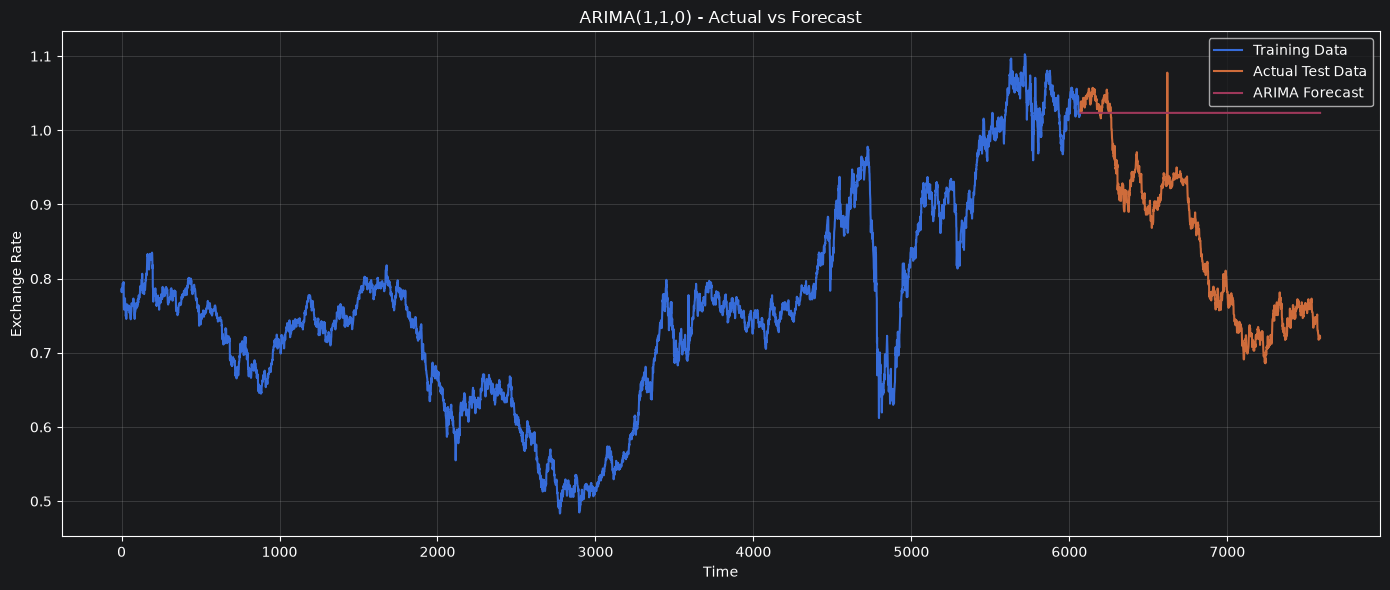

In [19]:
# Plot actual vs ARIMA forecast

plt.figure(figsize=(14, 6))

plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Test Data')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')

plt.title('ARIMA(1,1,0) - Actual vs Forecast')
plt.xlabel('Time')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
print("\nARIMA(1,1,0) Test Performance")
print("--------------------------------")
print("MAE :", mae_arima)
print("RMSE:", rmse_arima)
print("MAPE:", mape_arima, "%")


ARIMA(1,1,0) Test Performance
--------------------------------
MAE : 0.17764007140556395
RMSE: 0.2053585690039703
MAPE: 22.789105179052527 %


In [21]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit Exponential Smoothing model
exp_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal=None,
    initialization_method='estimated'
)

exp_fitted = exp_model.fit()

# Forecast the test period
exp_forecast = exp_fitted.forecast(len(test))

# Calculate evaluation metrics
mae_exp = mean_absolute_error(test, exp_forecast)
rmse_exp = np.sqrt(mean_squared_error(test, exp_forecast))
mape_exp = np.mean(np.abs((test - exp_forecast) / test)) * 100

print("Exponential Smoothing Test Performance")
print("---------------------------------------")
print("MAE :", mae_exp)
print("RMSE:", rmse_exp)
print("MAPE:", mape_exp, "%")

Exponential Smoothing Test Performance
---------------------------------------
MAE : 0.20659618979165734
RMSE: 0.23910443004601642
MAPE: 26.508663625599837 %


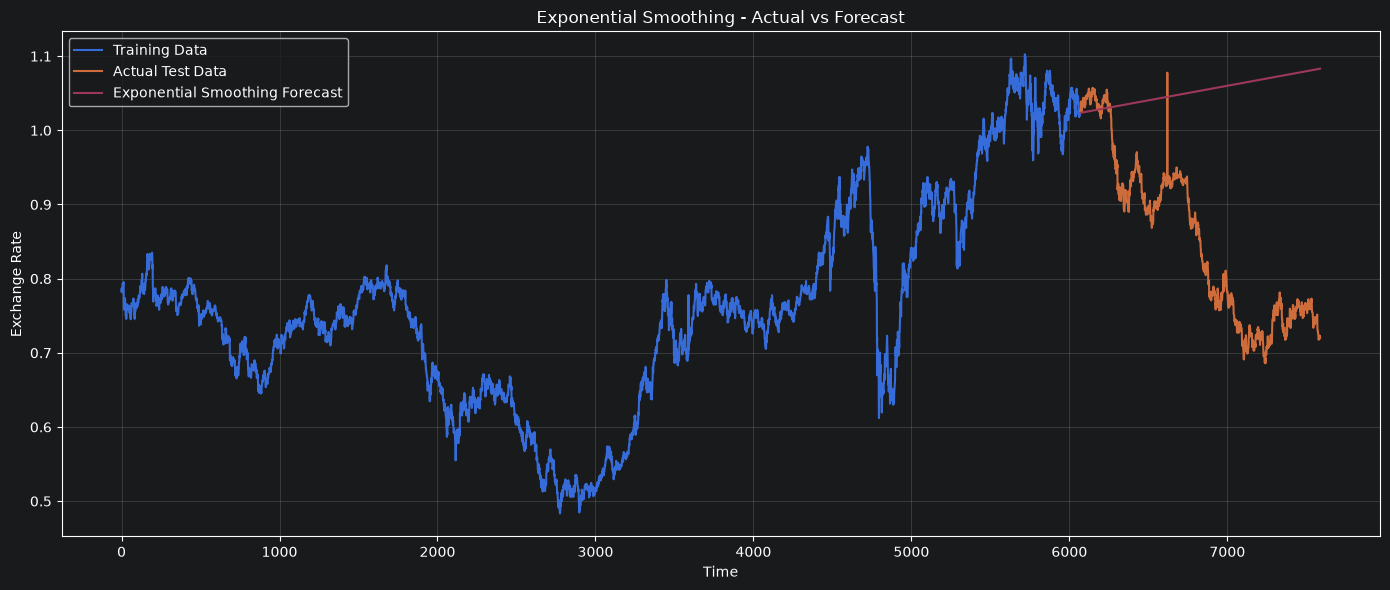

In [22]:
# Plot actual vs Exponential Smoothing forecast

plt.figure(figsize=(14, 6))

plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Test Data')
plt.plot(test.index, exp_forecast, label='Exponential Smoothing Forecast')

plt.title('Exponential Smoothing - Actual vs Forecast')
plt.xlabel('Time')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
print("Exponential Smoothing Test Performance")
print("---------------------------------------")
print("MAE :", mae_exp)
print("RMSE:", rmse_exp)
print("MAPE:", mape_exp, "%")

Exponential Smoothing Test Performance
---------------------------------------
MAE : 0.20659618979165734
RMSE: 0.23910443004601642
MAPE: 26.508663625599837 %


In [24]:
# Create final model comparison table

comparison = pd.DataFrame({
    'Model': [
        'ARIMA(1,1,0)',
        'Exponential Smoothing'
    ],
    'MAE': [
        mae_arima,
        mae_exp
    ],
    'RMSE': [
        rmse_arima,
        rmse_exp
    ],
    'MAPE (%)': [
        mape_arima,
        mape_exp
    ]
})

print("Final Model Comparison")
print("----------------------")
display(comparison)

Final Model Comparison
----------------------


,Model,MAE,RMSE,MAPE (%)
0,"ARIMA(1,1,0)",0.177640,0.205359,22.789105
1,Exponential Smoothing,0.206596,0.239104,26.508664


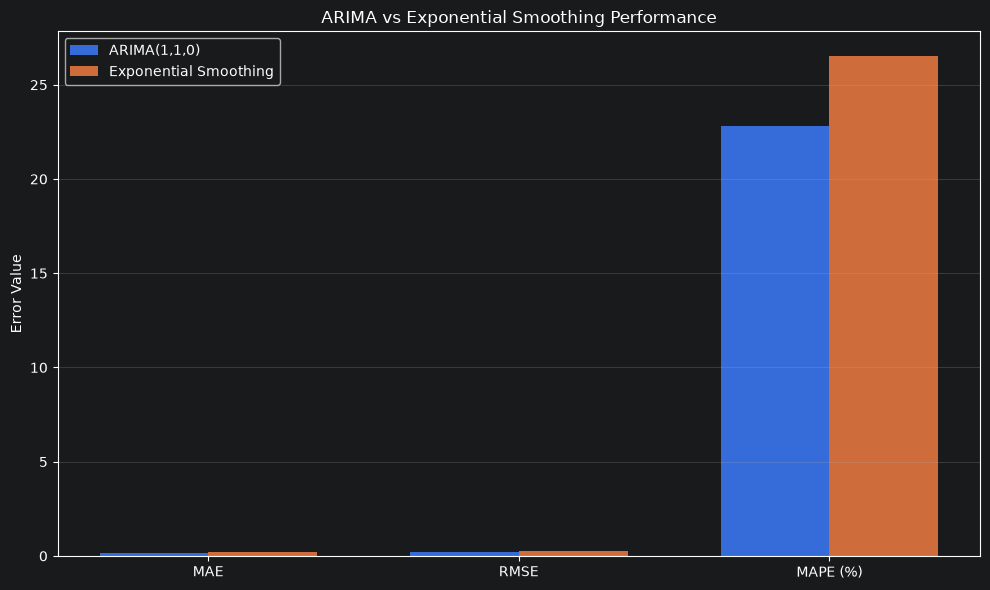

In [25]:
# Plot model performance comparison

metrics = ['MAE', 'RMSE', 'MAPE (%)']

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    [mae_arima, rmse_arima, mape_arima],
    width,
    label='ARIMA(1,1,0)'
)

plt.bar(
    x + width/2,
    [mae_exp, rmse_exp, mape_exp],
    width,
    label='Exponential Smoothing'
)

plt.xticks(x, metrics)
plt.ylabel('Error Value')
plt.title('ARIMA vs Exponential Smoothing Performance')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()